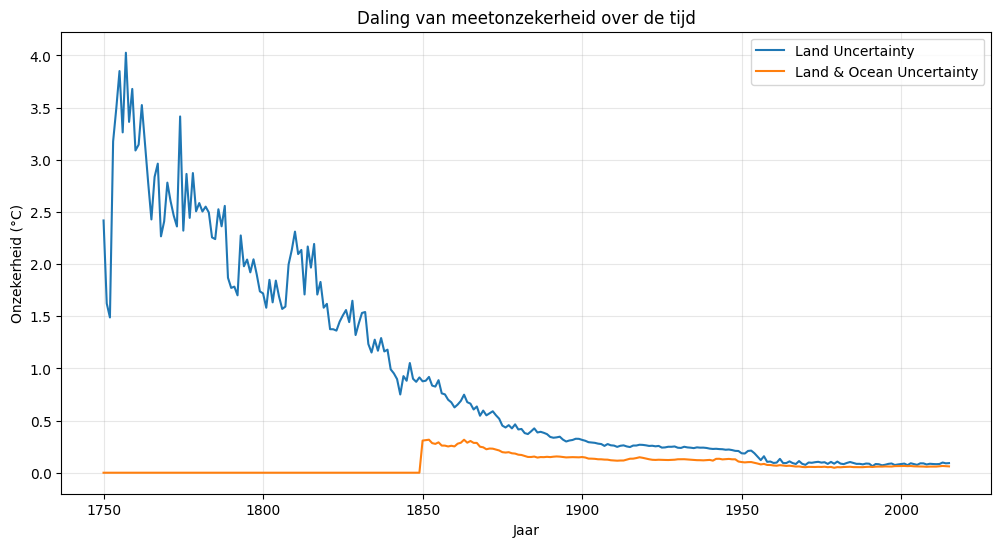

Analyse succesvol uitgevoerd!


In [5]:
import pandas as pd
import sqlalchemy as sa
import matplotlib.pyplot as plt
import seaborn as sns

# Verbinding herstellen
engine = sa.create_engine("mysql+pymysql://root:@localhost/climate_watch")

# 1. PAS HIER DE TABELNAAM AAN (bijv. 'global_temperatures' of 'GlobalTemperatures')
tabel_naam = 'global_temperatures' 

try:
    query = f"""
    SELECT dt, 
           LandAverageTemperatureUncertainty, 
           LandAndOceanAverageTemperatureUncertainty 
    FROM {tabel_naam}
    """
    df_unc = pd.read_sql(query, engine)
    
    # 2. Data verwerken
    df_unc['dt'] = pd.to_datetime(df_unc['dt'])
    df_unc['year'] = df_unc['dt'].dt.year
    
    # Groeperen per jaar voor de trend
    yearly_unc = df_unc.groupby('year')[['LandAverageTemperatureUncertainty', 'LandAndOceanAverageTemperatureUncertainty']].mean().reset_index()

    # 3. Visualisatie
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=yearly_unc, x='year', y='LandAverageTemperatureUncertainty', label='Land Uncertainty')
    sns.lineplot(data=yearly_unc, x='year', y='LandAndOceanAverageTemperatureUncertainty', label='Land & Ocean Uncertainty')

    plt.title('Daling van meetonzekerheid over de tijd')
    plt.xlabel('Jaar')
    plt.ylabel('Onzekerheid (°C)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("Analyse succesvol uitgevoerd!")

except Exception as e:
    print(f" Het is nog niet gelukt. Foutmelding: {e}")
    print("Check in phpMyAdmin of de tabelnaam klopt.")